# Explore here

K-Means: House grouping system

Step 1: Loading the dataset

In [1]:
import pandas as pd

total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

total_data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [17]:
import pandas as pd
import numpy as np
import json
import os

# 1. Cargar dataset
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

# 2. Simular una columna categórica (ejemplo: región según latitud)
def assign_region(lat):
    if lat > 38:
        return "North"
    elif lat > 35:
        return "Central"
    else:
        return "South"

total_data["region"] = total_data["Latitude"].apply(assign_region)

# 3. Factorizar columna 'region'
total_data["region_n"] = pd.factorize(total_data["region"])[0]

# 4. Crear diccionario de transformación
region_transformation_rules = {
    row["region"]: row["region_n"]
    for _, row in total_data[["region", "region_n"]].drop_duplicates().iterrows()
}

# 5. Crear carpeta y guardar JSON
os.makedirs("models/Transformations", exist_ok=True)

with open("models/Transformations/region_transformation_rules.json", "w") as f:
    json.dump(region_transformation_rules, f)

# 6. (Opcional) Verificar
print("✅ Factorización realizada y guardada como JSON.")
print(region_transformation_rules)


✅ Factorización realizada y guardada como JSON.
{'Central': 0, 'North': 1, 'South': 2}


In [18]:
import pandas as pd
import json
import os

# 1. Cargar el dataset
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

# 2. Generar copias con y sin outliers
data_con_outliers = total_data.copy()
data_sin_outliers = total_data.copy()

# 3. Función para reemplazar outliers con límites IQR
def replace_outliers_from_column(column, df):
    column_stats = df[column].describe()
    iqr = column_stats["75%"] - column_stats["25%"]
    upper_limit = column_stats["75%"] + 1.5 * iqr
    lower_limit = column_stats["25%"] - 1.5 * iqr
    if lower_limit < 0: lower_limit = 0
    # Reemplazar valores fuera de los límites
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy(), [lower_limit, upper_limit]

# 4. Lista de columnas numéricas para evaluar outliers
columns_to_check = [
    "MedInc", "HouseAge", "AveRooms", "AveBedrms",
    "Population", "AveOccup", "Latitude", "Longitude", "MedHouseVal"
]

# 5. Aplicar reemplazo de outliers y guardar los límites
outliers_dict = {}

for column in columns_to_check:
    data_sin_outliers, limits_list = replace_outliers_from_column(column, data_sin_outliers)
    outliers_dict[column] = limits_list

# 6. Guardar el diccionario como archivo JSON
os.makedirs("data/processed", exist_ok=True)

with open("data/processed/outliers_replacement.json", "w") as f:
    json.dump(outliers_dict, f)

# 7. (Opcional) Ver el resultado
print("✅ Reemplazo de outliers realizado. Límites guardados en JSON.")
print(outliers_dict)


✅ Reemplazo de outliers realizado. Límites guardados en JSON.
{'MedInc': [0, np.float64(8.013024999999999)], 'HouseAge': [0, np.float64(65.5)], 'AveRooms': [np.float64(2.0232191611709704), np.float64(8.46987802710694)], 'AveBedrms': [np.float64(0.8659085155701288), np.float64(1.2396965968190603)], 'Population': [0, np.float64(3132.0)], 'AveOccup': [np.float64(1.1509614824735064), np.float64(4.5610405893536905)], 'Latitude': [np.float64(28.259999999999998), np.float64(43.38)], 'Longitude': [0, np.float64(-112.32500000000002)], 'MedHouseVal': [0, np.float64(4.824124999999999)]}


In [19]:
import pandas as pd
import numpy as np
import os
from sklearn.model_selection import train_test_split

# 1. Cargar el dataset original
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

# 2. Crear copias del dataset con y sin outliers
data_con_outliers = total_data.copy()
data_sin_outliers = total_data.copy()

# 3. Función para reemplazar outliers con IQR
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0:
        lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy()

# 4. Reemplazar outliers en columnas numéricas
num_variables = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", 
                 "Population", "AveOccup", "Latitude", "Longitude", "MedHouseVal"]

for col in num_variables:
    data_sin_outliers = replace_outliers_from_column(col, data_sin_outliers)

# 5. Separar features (X) y target ficticio (y) → Usaremos 'MedHouseVal' como target (solo por ejemplo)
X_con_outliers = data_con_outliers.drop("MedHouseVal", axis=1)[num_variables[:-1]]  # Excluye target
X_sin_outliers = data_sin_outliers.drop("MedHouseVal", axis=1)[num_variables[:-1]]
y = data_con_outliers["MedHouseVal"]

# 6. Dividir en train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42)

X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42)

# 7. Ruta donde guardar (ajústala a tu sistema o usa raw string)
output_path = r"data/processed"  # Reemplaza esta ruta si trabajas en Windows y copias la completa

os.makedirs(output_path, exist_ok=True)

# 8. Guardar como Excel
X_train_con_outliers.to_excel(os.path.join(output_path, "X_train_con_outliers.xlsx"), index=False)
X_test_con_outliers.to_excel(os.path.join(output_path, "X_test_con_outliers.xlsx"), index=False)
X_train_sin_outliers.to_excel(os.path.join(output_path, "X_train_sin_outliers.xlsx"), index=False)
X_test_sin_outliers.to_excel(os.path.join(output_path, "X_test_sin_outliers.xlsx"), index=False)
y_train.to_excel(os.path.join(output_path, "y_train.xlsx"), index=False)
y_test.to_excel(os.path.join(output_path, "y_test.xlsx"), index=False)

print("✅ Datasets guardados en Excel en la carpeta:", output_path)


✅ Datasets guardados en Excel en la carpeta: data/processed


In [20]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset original
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

# 2. Copias con y sin outliers
data_con_outliers = total_data.copy()
data_sin_outliers = total_data.copy()

# 3. Reemplazo de outliers con IQR
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0: lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy()

# 4. Variables numéricas
num_vars = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", 
            "Population", "AveOccup", "Latitude", "Longitude"]

for col in num_vars:
    data_sin_outliers = replace_outliers_from_column(col, data_sin_outliers)

# 5. Features (X) y target (y)
X_con_outliers = data_con_outliers[num_vars]
X_sin_outliers = data_sin_outliers[num_vars]
y = data_con_outliers["MedHouseVal"]

# 6. Split train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42)

X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42)

# 7. Crear carpeta para guardar los normalizadores
scaler_path = r"models/Normalizers"
os.makedirs(scaler_path, exist_ok=True)

# 8. Normalizador con outliers
normalizador_con_outliers = StandardScaler()
normalizador_con_outliers.fit(X_train_con_outliers)

with open(os.path.join(scaler_path, "normalizador_con_outliers.pkl"), "wb") as file:
    pickle.dump(normalizador_con_outliers, file)

# 9. Normalizador sin outliers
normalizador_sin_outliers = StandardScaler()
normalizador_sin_outliers.fit(X_train_sin_outliers)

with open(os.path.join(scaler_path, "normalizador_sin_outliers.pkl"), "wb") as file:
    pickle.dump(normalizador_sin_outliers, file)

print("✅ Normalizadores guardados correctamente en:", scaler_path)


✅ Normalizadores guardados correctamente en: models/Normalizers


In [21]:
import pandas as pd
import numpy as np
import os
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Cargar el dataset original
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

# 2. Copias con y sin outliers
data_con_outliers = total_data.copy()
data_sin_outliers = total_data.copy()

# 3. Reemplazo de outliers con IQR
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0: lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy()

# 4. Variables numéricas
num_vars = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", 
            "Population", "AveOccup", "Latitude", "Longitude"]

for col in num_vars:
    data_sin_outliers = replace_outliers_from_column(col, data_sin_outliers)

# 5. Features (X) y target (y)
X_con_outliers = data_con_outliers[num_vars]
X_sin_outliers = data_sin_outliers[num_vars]
y = data_con_outliers["MedHouseVal"]

# 6. Split train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42)

X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42)

# 7. Crear carpetas necesarias
output_path = r"data/processed"
os.makedirs(output_path, exist_ok=True)

# 8. Cargar normalizadores desde los archivos .pkl (usando la misma ruta del paso 7)
with open("models/Normalizers/normalizador_con_outliers.pkl", "rb") as file:
    normalizador_con_outliers = pickle.load(file)

with open("models/Normalizers/normalizador_sin_outliers.pkl", "rb") as file:
    normalizador_sin_outliers = pickle.load(file)

# 9. Aplicar transformación (normalización)
X_train_con_norm = normalizador_con_outliers.transform(X_train_con_outliers)
X_test_con_norm = normalizador_con_outliers.transform(X_test_con_outliers)

X_train_sin_norm = normalizador_sin_outliers.transform(X_train_sin_outliers)
X_test_sin_norm = normalizador_sin_outliers.transform(X_test_sin_outliers)

# 10. Convertir a DataFrame
X_train_con_norm_df = pd.DataFrame(X_train_con_norm, columns=num_vars)
X_test_con_norm_df = pd.DataFrame(X_test_con_norm, columns=num_vars)

X_train_sin_norm_df = pd.DataFrame(X_train_sin_norm, columns=num_vars)
X_test_sin_norm_df = pd.DataFrame(X_test_sin_norm, columns=num_vars)

# 11. Guardar como Excel
X_train_con_norm_df.to_excel(os.path.join(output_path, "X_train_con_outliers_norm.xlsx"), index=False)
X_test_con_norm_df.to_excel(os.path.join(output_path, "X_test_con_outliers_norm.xlsx"), index=False)
X_train_sin_norm_df.to_excel(os.path.join(output_path, "X_train_sin_outliers_norm.xlsx"), index=False)
X_test_sin_norm_df.to_excel(os.path.join(output_path, "X_test_sin_outliers_norm.xlsx"), index=False)

print("✅ Datasets normalizados guardados en Excel en:", output_path)


✅ Datasets normalizados guardados en Excel en: data/processed


In [22]:
import pandas as pd
import numpy as np
import pickle
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

# 1. Cargar el dataset
total_data = pd.read_csv("https://raw.githubusercontent.com/4GeeksAcademy/k-means-project-tutorial/main/housing.csv")

# 2. Copias con y sin outliers
data_con_outliers = total_data.copy()
data_sin_outliers = total_data.copy()

# 3. Reemplazo de outliers con IQR
def replace_outliers_from_column(column, df):
    stats = df[column].describe()
    iqr = stats["75%"] - stats["25%"]
    upper_limit = stats["75%"] + 1.5 * iqr
    lower_limit = stats["25%"] - 1.5 * iqr
    if lower_limit < 0: lower_limit = 0
    df[column] = df[column].apply(lambda x: x if x <= upper_limit else upper_limit)
    df[column] = df[column].apply(lambda x: x if x >= lower_limit else lower_limit)
    return df.copy()

# 4. Variables numéricas
num_vars = ["MedInc", "HouseAge", "AveRooms", "AveBedrms", 
            "Population", "AveOccup", "Latitude", "Longitude"]

for col in num_vars:
    data_sin_outliers = replace_outliers_from_column(col, data_sin_outliers)

# 5. Features (X) y target (y)
X_con_outliers = data_con_outliers[num_vars]
X_sin_outliers = data_sin_outliers[num_vars]
y = data_con_outliers["MedHouseVal"]

# 6. Dividir en train/test
X_train_con_outliers, X_test_con_outliers, y_train, y_test = train_test_split(
    X_con_outliers, y, test_size=0.2, random_state=42)

X_train_sin_outliers, X_test_sin_outliers = train_test_split(
    X_sin_outliers, test_size=0.2, random_state=42)

# 7. Crear carpetas para guardar resultados
scaler_path = "models/Scalers"
output_path = "data/processed"
os.makedirs(scaler_path, exist_ok=True)
os.makedirs(output_path, exist_ok=True)

# 8. Escalado con MinMaxScaler y guardado de scalers

# CON OUTLIERS
scaler_con = MinMaxScaler()
scaler_con.fit(X_train_con_outliers)

with open(os.path.join(scaler_path, "scaler_con_outliers.pkl"), "wb") as file:
    pickle.dump(scaler_con, file)

X_train_con_scaled = scaler_con.transform(X_train_con_outliers)
X_test_con_scaled = scaler_con.transform(X_test_con_outliers)

# SIN OUTLIERS
scaler_sin = MinMaxScaler()
scaler_sin.fit(X_train_sin_outliers)

with open(os.path.join(scaler_path, "scaler_sin_outliers.pkl"), "wb") as file:
    pickle.dump(scaler_sin, file)

X_train_sin_scaled = scaler_sin.transform(X_train_sin_outliers)
X_test_sin_scaled = scaler_sin.transform(X_test_sin_outliers)

# 9. Convertir a DataFrames
X_train_con_scaled_df = pd.DataFrame(X_train_con_scaled, columns=num_vars)
X_test_con_scaled_df = pd.DataFrame(X_test_con_scaled, columns=num_vars)
X_train_sin_scaled_df = pd.DataFrame(X_train_sin_scaled, columns=num_vars)
X_test_sin_scaled_df = pd.DataFrame(X_test_sin_scaled, columns=num_vars)

# 10. Guardar en Excel
X_train_con_scaled_df.to_excel(os.path.join(output_path, "X_train_con_outliers_scal.xlsx"), index=False)
X_test_con_scaled_df.to_excel(os.path.join(output_path, "X_test_con_outliers_scal.xlsx"), index=False)
X_train_sin_scaled_df.to_excel(os.path.join(output_path, "X_train_sin_outliers_scal.xlsx"), index=False)
X_test_sin_scaled_df.to_excel(os.path.join(output_path, "X_test_sin_outliers_scal.xlsx"), index=False)

print("✅ Min-Max scalers y datasets escalados guardados correctamente.")


✅ Min-Max scalers y datasets escalados guardados correctamente.


Removing unuseful variables

In [2]:
X = total_data[["MedInc", "Latitude", "Longitude"]]
X.head()

,MedInc,Latitude,Longitude
0,8.3252,37.88,-122.23
1,8.3014,37.86,-122.22
2,7.2574,37.85,-122.24
3,5.6431,37.85,-122.25
4,3.8462,37.85,-122.25


Divide the dataset into train and test

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(X, test_size = 0.2, random_state = 42)

X_train.head()

,MedInc,Latitude,Longitude
14196,3.2596,32.71,-117.03
8267,3.8125,33.77,-118.16
17445,4.1563,34.66,-120.48
14265,1.9425,32.69,-117.11
2271,3.5542,36.78,-119.80


Step 2: Build a K-Means

In [4]:
from sklearn.cluster import KMeans

model_unsup = KMeans(n_clusters = 6, n_init = "auto", random_state = 42)
model_unsup.fit(X_train)

KMeans(n_clusters=6, random_state=42)


Insert clusters to the train dataset

In [5]:
y_train = list(model_unsup.labels_)
X_train["cluster"] = y_train
X_train.head()

,MedInc,Latitude,Longitude,cluster
14196,3.2596,32.71,-117.03,3
8267,3.8125,33.77,-118.16,1
17445,4.1563,34.66,-120.48,1
14265,1.9425,32.69,-117.11,3
2271,3.5542,36.78,-119.80,5


Plotting results

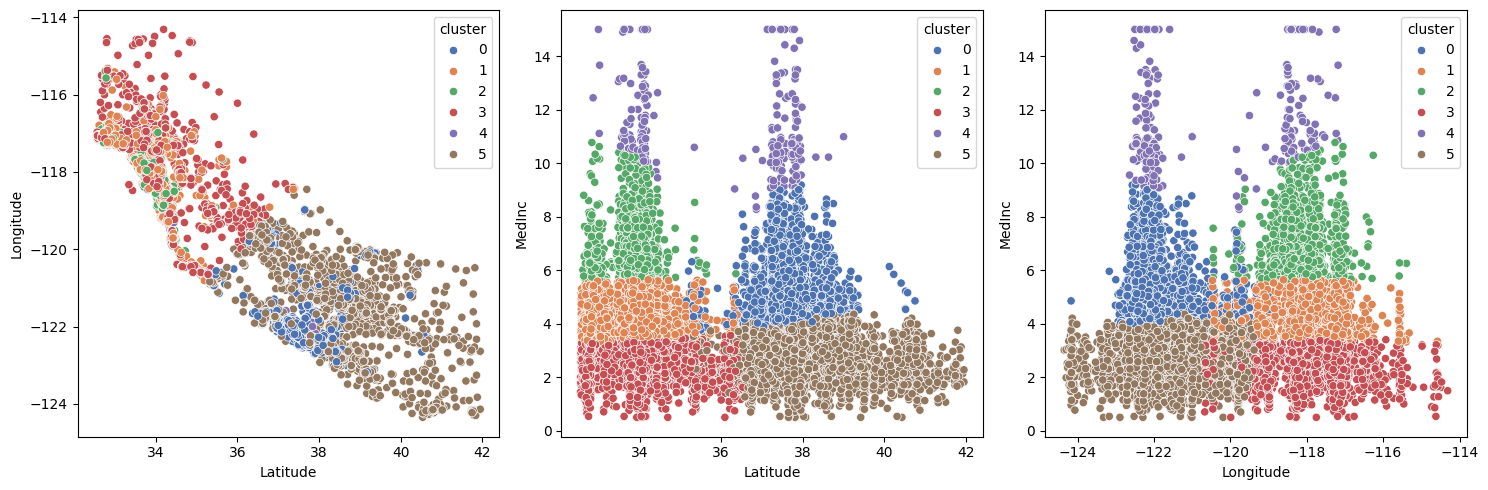

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep")
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep")
plt.tight_layout()

plt.show()

Step 3: Predict with the test set

In [7]:
y_test = list(model_unsup.predict(X_test))
X_test["cluster"] = y_test
X_test.head()

,MedInc,Latitude,Longitude,cluster
20046,1.6812,36.06,-119.01,3
3024,2.5313,35.14,-119.46,3
15663,3.4801,37.80,-122.44,5
20484,5.7376,34.28,-118.72,2
9814,3.7250,36.62,-121.93,5


Plotting test results over above figure

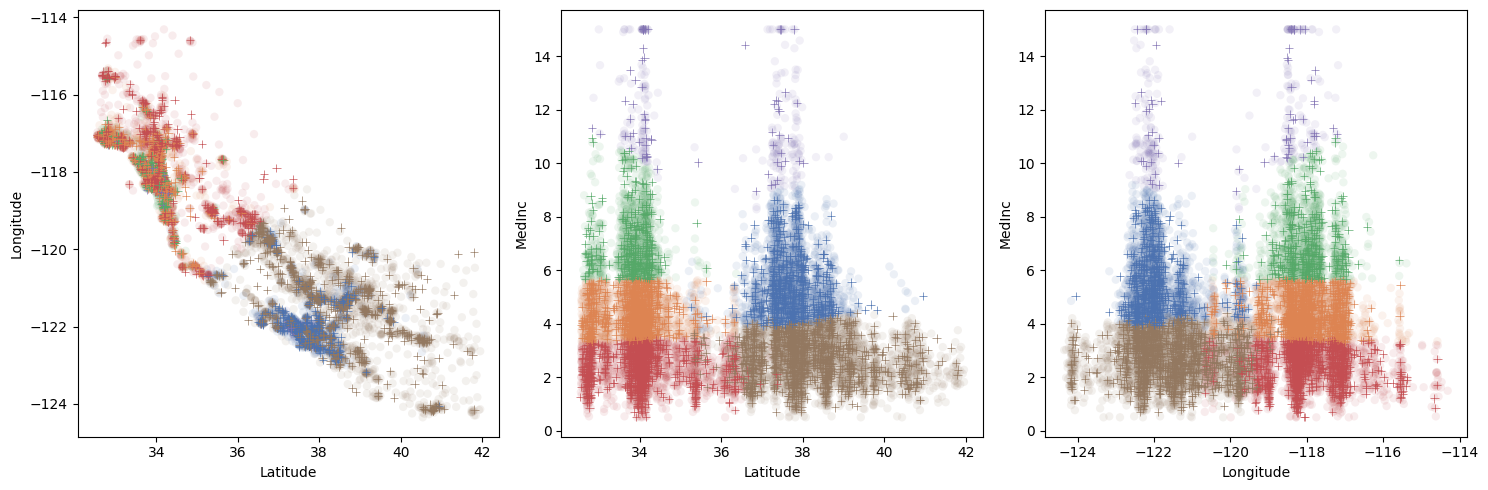

In [8]:
fig, axis = plt.subplots(1, 3, figsize = (15, 5))

sns.scatterplot(ax = axis[0], data = X_train, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep", alpha  = 0.1)
sns.scatterplot(ax = axis[1], data = X_train, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep", alpha  = 0.1)
sns.scatterplot(ax = axis[2], data = X_train, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep", alpha  = 0.1)

sns.scatterplot(ax = axis[0], data = X_test, x = "Latitude", y = "Longitude", hue = "cluster", palette = "deep", marker = "+")
sns.scatterplot(ax = axis[1], data = X_test, x = "Latitude", y = "MedInc", hue = "cluster", palette = "deep", marker = "+")
sns.scatterplot(ax = axis[2], data = X_test, x = "Longitude", y = "MedInc", hue = "cluster", palette = "deep", marker = "+")

plt.tight_layout()

for ax in axis:
    ax.legend([],[], frameon=False)

plt.show()

As we can see, there is a high reliability in predicting to which cluster each test point belongs.

Step 4: Train a supervised classification model

I have chosen a Decision Tree because it is a very good alternative when we want to categorize elements according to their intrinsic characteristics, and there is no clear linear relationship between some variables. In addition, it is not necessary to standardize the values.

In [9]:
from sklearn.tree import DecisionTreeClassifier

model_sup = DecisionTreeClassifier(random_state = 42)
model_sup.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

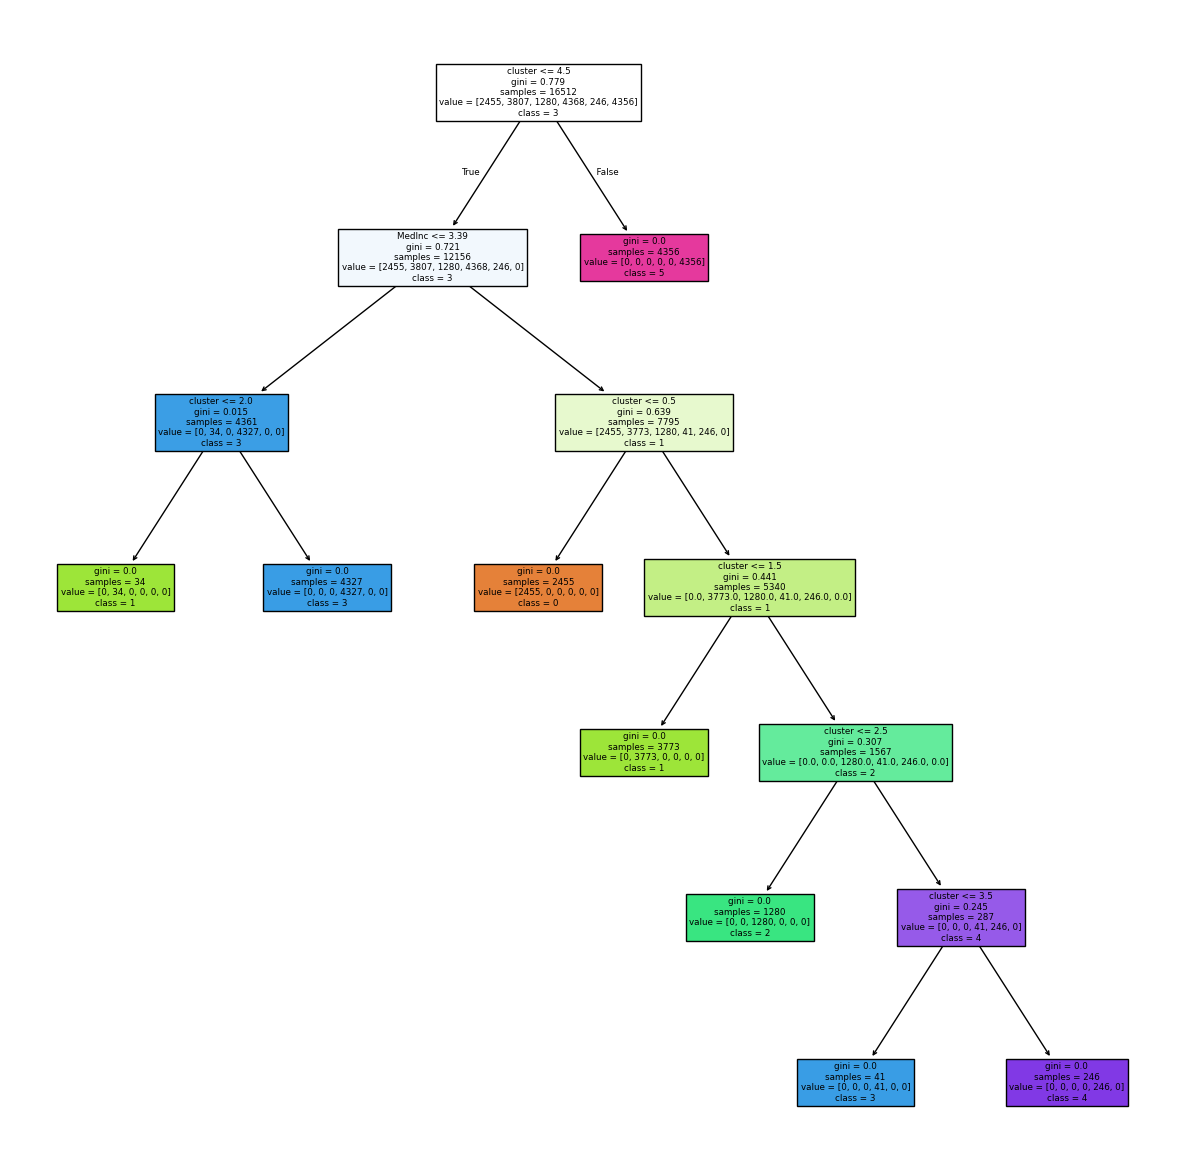

In [10]:
from sklearn import tree

fig = plt.figure(figsize=(15,15))

tree.plot_tree(model_sup, feature_names = list(X_train.columns), class_names = ["0", "1", "2", "3", "4", "5"], filled = True)

plt.show()

In [11]:
y_pred = model_sup.predict(X_test)
y_pred

array([3, 3, 5, ..., 4, 5, 1], shape=(4128,), dtype=int32)

In [12]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

1.0

Step 5: Save the models

In [15]:
import os

# Crea la carpeta 'models' si no existe
os.makedirs("models", exist_ok=True)


In [16]:
from pickle import dump

# Guardar modelos supervisado y no supervisado
dump(model_unsup, open("models/k-means_default_42.sav", "wb"))
dump(model_sup, open("models/decision_tree_classifier_default_42.sav", "wb"))
